# KV Caching
When pre-training GPTs we calculate $q$, $k$ and $v$ vectors for each tokens on each forward pass. We need to this as train the prediction of each token along the input sequence simultaneously.
For inference, however, this approach is not optimal. Due to the autoregressive nature GPTs each token of the context is typically passed through model everytime a new token is added to the end of the context. This leads to two inefficiencies:
- The $k$ and $v$ vectors are recalculated on each forward call
- The $q$ vectors are also recalculated for each token, however, we only need the $q$ vector for the last token in the sequence[CHECK]
In this notebook we will demonstrate how to fix theses inefficiencies. The former by introducing KC-caching, the latter by some algorithmic adjustments.

## The problem
Let's start by demonstrating the problem. We instantiate a very small GPTModel (the model is not trained and the output will be gibberish but that does not matter for this demonstration) with a single tranformer block containing just one attention head. We then register hooks so that we can monitor the calculated $q$, $k$ and $v$ vectors which are normally internal to the model.


In [1]:
%load_ext autoreload
%autoreload 2

In [71]:
import tiktoken
import torch

from sturnus.models import GPTModel
from sturnus.util import text_to_tokens, tokens_to_text


GPT_CONFIG_one_attention_head = {
    'vocab_size': 50257,
    'block_size': 1024,
    'count_heads': 1,
    'count_blocks': 1,
    'embed_dim': 768,
    'dropout': 0.1,
    'qkv_bias': True, # Used in GPT2 but typically not in modern LLMs as the biases do not improve performance
}

model_one_att = GPTModel(GPT_CONFIG_one_attention_head)
model_one_att.eval();

In [3]:
captured_values = {}

def attach_hook(layer_name):
    captured_values[layer_name] = []

    def hook(module, input, output):
       captured_values[layer_name].append(output.detach())
    
    return hook

model_one_att.trf_blocks[0].att.W_Q.register_forward_hook(attach_hook('Q'))
model_one_att.trf_blocks[0].att.W_K.register_forward_hook(attach_hook('K'))
model_one_att.trf_blocks[0].att.W_V.register_forward_hook(attach_hook('V'));

In [4]:
tokenizer = tiktoken.get_encoding("gpt2")

tokens = text_to_tokens('Hi', tokenizer)

for i in range(3):
    with torch.no_grad():
        logits = model_one_att.forward(tokens)
    logits = logits[:, -1, :]
    idx_next = torch.argmax(logits, dim=-1, keepdim=True)
    tokens = torch.cat((tokens, idx_next), dim=1)


In [5]:
torch.set_printoptions(edgeitems=2)
torch.set_printoptions(threshold=10)

for name in captured_values:
    for i, v in enumerate(captured_values[name]):
        print(f'{name} iter {i+1}:')
        print(v)

Q iter 1:
tensor([[[-0.4946, -1.3738,  ..., -1.0353, -0.9985]]])
Q iter 2:
tensor([[[-0.4946, -1.3738,  ..., -1.0353, -0.9985],
         [-0.0741, -0.0415,  ...,  0.2580, -0.2727]]])
Q iter 3:
tensor([[[-0.4946, -1.3738,  ..., -1.0353, -0.9985],
         [-0.0741, -0.0415,  ...,  0.2580, -0.2727],
         [ 0.4068, -0.0612,  ...,  0.0610,  0.5906]]])
K iter 1:
tensor([[[ 0.0966,  0.4050,  ..., -0.1200, -0.5535]]])
K iter 2:
tensor([[[ 0.0966,  0.4050,  ..., -0.1200, -0.5535],
         [-0.0625, -0.8533,  ...,  0.1146, -0.1630]]])
K iter 3:
tensor([[[ 0.0966,  0.4050,  ..., -0.1200, -0.5535],
         [-0.0625, -0.8533,  ...,  0.1146, -0.1630],
         [ 0.7481, -0.0049,  ...,  0.9973, -0.4712]]])
V iter 1:
tensor([[[-0.7746, -0.7189,  ...,  0.0270, -0.3118]]])
V iter 2:
tensor([[[-0.7746, -0.7189,  ...,  0.0270, -0.3118],
         [-1.4380,  1.1911,  ..., -0.3094, -0.1119]]])
V iter 3:
tensor([[[-0.7746, -0.7189,  ...,  0.0270, -0.3118],
         [-1.4380,  1.1911,  ..., -0.3094, -0.

We can here see that the $k$ and $v$ (and indeed $q$) vectors are recalculated for all the preceding tokens on each new evaluation of the model as we generate a string of output text.

## The solution
Below we will demonstrate implementation of KV-caching and the speed-up that it gives. The implementation of the GPT model with KV-caching can be found [here](https://github.com/crs17/sturnus/blob/main/src/sturnus/models/gpt2_kv_cache.py).

In [6]:
from sturnus.models import GPTKVCache

GPT_CONFIG_124_openai = {
    'vocab_size': 50257,
    'block_size': 1024,
    'count_heads': 12,
    'count_blocks': 12,
    'embed_dim': 768,
    'dropout': 0.1,
    'qkv_bias': True, # Used in GPT2 but typically not in modern LLMs as the biases do not improve performance
}

model_kv = GPTKVCache(GPT_CONFIG_124_openai)


In [7]:
from sturnus.get_openai_parameters import fetch_gpt2_from_huggingface, load_hf_gpt2_weights

openai_state_dict = fetch_gpt2_from_huggingface()
load_hf_gpt2_weights(model_kv, openai_state_dict)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [75]:
import time


def generate_kv(model, start_tokens, count_new_tokens, use_cache=False):
    model.eval()
    # torch.manual_seed(42)

    tokens = start_tokens
    model.reset_cache()

    token_times = [time.time()]
    for i in range(count_new_tokens):
        with torch.no_grad():
            if use_cache:
                logits = model.forward(tokens[:, -1:], use_cache=use_cache)
            else:
                logits = model.forward(tokens, use_cache=use_cache)
        logits = logits[:, -1, :]
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        tokens = torch.cat((tokens, idx_next), dim=1)
        token_times.append(time.time())

    token_times = [t - token_times[0] for t in token_times]
    return tokens, token_times

N = 200
new_tokens_no_cache, times_no_cache = generate_kv(model_kv, text_to_tokens('Hi', tokenizer), count_new_tokens=N, use_cache=False)
new_tokens_cache, times_cache = generate_kv(model_kv, text_to_tokens('Hi', tokenizer), count_new_tokens=N, use_cache=True)

We see that the model produce the same output with and without caching which is a nice sanity check:

In [76]:
tokens_to_text(new_tokens_no_cache, tokenizer)

"Hi. I'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of"

In [77]:
tokens_to_text(new_tokens_cache, tokenizer)

"Hi. I'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of this.\n\nI'm sorry, but I'm not sure if you're aware of this. I'm not sure if you're aware of"

Plotting the computation time as function of the number of tokens generated, we see that the time grows linearly for the cached version of the model. The non-cached version sees computation time growning much faster leading to a very significant speed-up when using KV-caching.

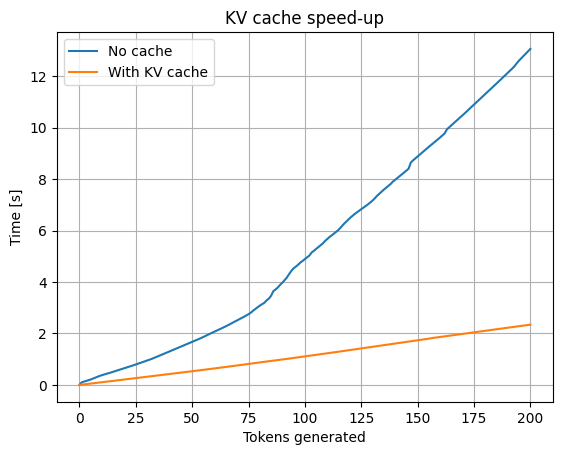

In [70]:
import matplotlib.pylab as plt

fig, ax = plt.subplots()

ax.plot(times_no_cache, label='No cache')
ax.plot(times_cache, label='With KV cache')

ax.set_title('KV cache speed-up')
ax.set_xlabel('Tokens generated')
ax.set_ylabel('Time [s]')

ax.grid()

ax.legend();



